In [2]:
### Imports
from time import thread_time_ns
import numpy as np
from pathlib import Path
import random
import itertools
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np
import json
import math
import pprint
import pandas as pd
from time import thread_time_ns
from datetime import datetime
import statistics


Find the center - our current pipeline

In [3]:
def detection(thresholds,blob_params, gray):
    detector = cv.SimpleBlobDetector_create(blob_params)
    centers= []
    for thresh in thresholds:
        _, thresholded = cv.threshold(gray, thresh, 255, cv.THRESH_BINARY)
        keypoints = detector.detect(thresholded)
        current_centers = [(round(kp.pt[0]), round(kp.pt[1])) for kp in keypoints]
        new_centers = []
        for curr_center in current_centers:
            isNew = True
            for c in centers:
                    distance = math.dist(curr_center, c)
                    isNew = distance >= 10
                    if not isNew:
                        break
            if isNew:
                new_centers.append(curr_center)
        centers = centers + new_centers
    return centers


def blobParamFunc(minArea, minCircularity):
    params = cv.SimpleBlobDetector_Params()
    params.filterByCircularity = True
    params.minCircularity = minCircularity
    params.minArea=minArea
    params.blobColor = 0
    return params

In [327]:
file_path = "/Users/jdreiling/Desktop/puck/puck/images/custom/jack_cole/medium/A/custom_jack_cole_medium_A_0.jpg"
image = cv.imread(file_path, cv.IMREAD_COLOR_RGB)
imageBlurred = cv.medianBlur(image, 3)
gray = cv.cvtColor(imageBlurred, cv.COLOR_RGBA2GRAY)
thresholds = np.arange(160,190,10)
blob_params = blobParamFunc(400, .8)
point_list = detection(thresholds=thresholds, blob_params= blob_params, gray=gray)
print(point_list)

[(761, 702), (1067, 603), (608, 231), (915, 137)]


In [328]:
print(point_list)

[(761, 702), (1067, 603), (608, 231), (915, 137)]


Find the pixels around the center, block of 10 by 10 around that center, so 5 up and 5 down etc


In [34]:
def getDotList(point_list, side, image):
    dot_list = []
    for pt in point_list:
        x,y= pt
        x_adjusted = x-side
        y_adjusted = y-side
        if x_adjusted < 0:
            x_adjusted = 0
        if y_adjusted <0:
            y_adjusted = 0
        crop_img = image[y_adjusted:y+side,x_adjusted:x+side]
        dot_list.append((crop_img, (x,y)))
    return dot_list

In [ ]:
def getColorCoords(dot_list, side):
    colorCoords = []
    for dot_pair in dot_list:
        dot = dot_pair[0]
        plt.imshow(dot)
        x,y = dot_pair[1]
        maxPixel = (side*2)-1
        points = [dot[0,maxPixel],dot[maxPixel,0],dot[0,maxPixel],dot[maxPixel,maxPixel]]
        print(points)
        baselineWhite = [max([points[i][0] for i in range(0,4)]),
                        max([points[i][1] for i in range(0,4)]),
                        max([points[i][2] for i in range(0,4)])]
        print("x and y is")
        print(x)
        print(y)
        circleColor = image[y,x]
        print("circle color")
        print(circleColor)
        new = [round(circleColor[0]/baselineWhite[0]*255),
            round(circleColor[1]/baselineWhite[1]*255),
            round(circleColor[2]/baselineWhite[2]*255)]
        colorCoords.append((dot_pair[1], new))
        print(colorCoords)
    return colorCoords

def getBlackDot(colorCoords):
    colorCoords_hsv = []
    for c in colorCoords:
        colorCoords_hsv.append((c[0],colorsys.rgb_to_hsv(c[1][0]/255, c[1][1]/255,c[1][2]/255)))
    values = [hsv[1][2] for hsv in colorCoords_hsv]
    blackDot = (colorCoords[values.index(min(values))])
    return blackDot


# colorCoords = []
# for dot_pair in dot_list:
#     dot = dot_pair[0]
#     x,y = dot_pair[1]
#     maxPixel = (side*2)-1
#     points = [dot[0,maxPixel],dot[maxPixel,0],dot[0,maxPixel],dot[maxPixel,maxPixel]]
#     baselineWhite = [max([points[i][0] for i in range(0,4)]),
#                      max([points[i][1] for i in range(0,4)]),
#                      max([points[i][2] for i in range(0,4)])]
#     circleColor = image[y,x]
#     new = [round(circleColor[0]/baselineWhite[0]*255),
#            round(circleColor[1]/baselineWhite[1]*255),
#            round(circleColor[2]/baselineWhite[2]*255)]
#     hsv = (colorsys.rgb_to_hsv(new[0]/255, new[1]/255,new[2]/255))
#     colorCoords.append((dot_pair[1], new))
#     colorCoords_hsv.append((dot_pair[1], hsv))




In [330]:
for b in zip(dot_list):
    print(b[0][1])

(761, 702)
(1067, 603)
(608, 231)
(915, 137)


In [165]:
print(dot_list[0])

(array([[[169, 185, 211],
        [169, 185, 211],
        [169, 185, 211],
        ...,
        [171, 186, 215],
        [171, 187, 213],
        [171, 187, 213]],

       [[169, 185, 210],
        [169, 185, 210],
        [170, 184, 211],
        ...,
        [172, 186, 215],
        [171, 187, 213],
        [171, 187, 213]],

       [[169, 185, 210],
        [169, 185, 210],
        [170, 184, 211],
        ...,
        [172, 186, 215],
        [171, 187, 213],
        [171, 187, 213]],

       ...,

       [[170, 182, 206],
        [170, 182, 206],
        [170, 182, 206],
        ...,
        [167, 181, 207],
        [169, 180, 208],
        [169, 180, 208]],

       [[168, 183, 206],
        [169, 181, 205],
        [169, 181, 205],
        ...,
        [167, 181, 207],
        [169, 180, 208],
        [169, 180, 208]],

       [[167, 182, 205],
        [167, 182, 205],
        [167, 182, 205],
        ...,
        [167, 183, 208],
        [167, 181, 208],
        [167, 181, 208]

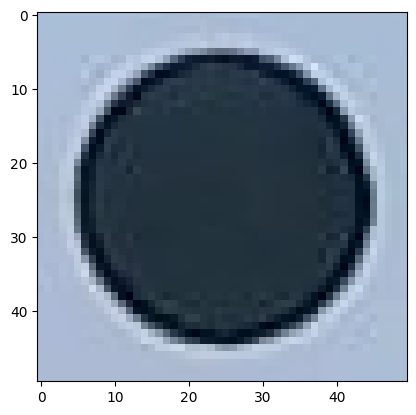

In [125]:
plt.imshow(dot_list[1])

In [25]:
import colorsys

In [ ]:
colorCoords_hsv = []
colorCoords = []
for dot_pair in dot_list:
    dot = dot_pair[0]
    x,y = dot_pair[1]
    maxPixel = (side*2)-1
    points = [dot[0,maxPixel],dot[maxPixel,0],dot[0,maxPixel],dot[maxPixel,maxPixel]]
    baselineWhite = [max([points[i][0] for i in range(0,4)]),
                     max([points[i][1] for i in range(0,4)]),
                     max([points[i][2] for i in range(0,4)])]
    circleColor = image[y,x]
    new = [round(circleColor[0]/baselineWhite[0]*255),
           round(circleColor[1]/baselineWhite[1]*255),
           round(circleColor[2]/baselineWhite[2]*255)]
    hsv = (colorsys.rgb_to_hsv(new[0]/255, new[1]/255,new[2]/255))
    colorCoords.append((dot_pair[1], new))
    colorCoords_hsv.append((dot_pair[1], hsv))

values = [hsv[1][2] for hsv in colorCoords_hsv]
blackDot =(colorCoords[values.index(min(values))])

In [ ]:
print(blackDot[1])

((1067, 603), [49, 67, 71])


In [44]:
from dataclasses import dataclass


@dataclass
class Point:
    x: float = 0.0
    y: float = 0.0

    @classmethod
    def from_tuple(cls, coords):
        return cls(coords[0], coords[1])

    def as_tuple(self):
        return (self.x, self.y)



In [ ]:
newPoints = [Point.from_tuple(pt) for pt in point_list]
print(newPoints)

[Point(x=761, y=702), Point(x=1067, y=603), Point(x=608, y=231), Point(x=915, y=137)]


In [45]:
from itertools import combinations
# compute all the unordered pairs
pairs = list(combinations(newPoints, 2))
print(pairs)
print(f"There are {len(pairs)} pairs of points.")

NameError: name 'newPoints' is not defined

In [130]:
from math import hypot

def bucket(value: float, size: float):
    # print(value, int(value / size))
    return int(value / size)

def euc_dist(a: Point, b: Point) -> float:
    return hypot(b.x - a.x, b.y - a.y)


# bucketed = [bucket(round(euc_dist(a, b)), 50) for a, b in pairs]
# print(bucketed)
# print(f"There are {len(list(set(bucketed)))} pairs of different distances.")

In [ ]:
from collections import defaultdict


tally = defaultdict(list)
for pair, dist in zip(pairs, bucketed):
    tally[dist].append(pair)
same_distance_pairs = dict(
    ((dist, pairs) for dist, pairs in tally.items() if len(pairs) > 1)
)
same_distance_pairs

{16: [(Point(x=761, y=702), Point(x=1067, y=603)),
  (Point(x=608, y=231), Point(x=915, y=137))],
 24: [(Point(x=761, y=702), Point(x=608, y=231)),
  (Point(x=1067, y=603), Point(x=915, y=137))],
 29: [(Point(x=761, y=702), Point(x=915, y=137)),
  (Point(x=1067, y=603), Point(x=608, y=231))]}

In [69]:

def same_midpoint(pairA, pairB, threshold=20):
    # note - threshold is in pixels
    def midpoint(pair):
        a, b = pair
        return Point((b.x - a.x) / 2.0, (b.y - a.y) / 2.0)

    # compute the midpoints of each pair
    midA = midpoint(pairA)
    midB = midpoint(pairB)

    # are they the same? or rather are they some delta distant
    distance = euc_dist(midA, midB)

    return distance < threshold


all_rects = []
for _, pairs in same_distance_pairs.items():
    pairs_of_pairs = combinations(pairs, 2)
    rects = [(p1, p2) for (p1, p2) in pairs_of_pairs if same_midpoint(p1, p2)]
    all_rects.extend(rects)

print(all_rects)

for rect in all_rects:
    print(rect)
    print()

NameError: name 'same_distance_pairs' is not defined

In [286]:
for rects in all_rects:
    print("rect")
    print(rects)

rect
((Point(x=761, y=702), Point(x=1067, y=603)), (Point(x=608, y=231), Point(x=915, y=137)))
rect
((Point(x=761, y=702), Point(x=608, y=231)), (Point(x=1067, y=603), Point(x=915, y=137)))


In [ ]:
out = image.copy()


def point_as_ints(point):
    return int(point[0]), int(point[1])


def checkRects(all_rects):
    checked = []
    for rect in all_rects:
        p0, p2 = rect[0]
        p1, p3 = rect[1]
        rect_point_list = [p0, p2, p1, p3]
        target = Point(0,0)
        rect_point_list.sort(key= lambda p: euc_dist(p, target))
        if rect_point_list not in checked:
            checked.append(rect_point_list)
    return checked



def orderedPermutation(black_dot, dots):
    ## black dot has the coordinates for the black dot
    if black_dot not in dots:
        print("Black Dot Not in Dots given, something is wrong!")
    dots.remove(black_dot)
    black_dot_distances = [(math.dist(black_dot,d),d)for d in dots]
    black_dot_distances.sort(key= lambda p: p[0])
    ordered = [black_dot_distances[0][1], black_dot_distances[2][1],black_dot_distances[1][1]]
    return ordered

def displayFoundRect(checked, image):
    out = image.copy()

    for rect in checked:
        p0, p1, p2, p3 = rect
        p0, p2, p1, p3 = p0.as_tuple(), p2.as_tuple(), p1.as_tuple(), p3.as_tuple()
        p0, p2, p1, p3 = [point_as_ints(p) for p in [p0, p2, p1, p3]]

        cv.line(out, p0, p2, (255, 0, 0), 10)
        cv.line(out, p0, p1, (255, 0, 0), 10)
        cv.line(out, p3, p1, (255, 0, 0), 10)
        cv.line(out, p3, p2, (255, 0, 0), 10)

    plt.imshow(out)
    plt.show()


    perm_list = [p0,p1,p2,p3]
        ordered = orderedPermutation(blackDot[0], perm_list)
        print(ordered)

In [143]:
trueColors_custom = {(253, 22, 34):'a',
                      (254, 0, 255):'b',
                      (0, 254,22): 'c',
                      (0, 132, 254): 'd',
                      (254, 170, 13): 'e',
                      (219, 79, 137): 'f',
                      (235,251, 38): 'g',
                      (0, 248, 196): 'h'}

print(trueColors_custom.keys())

dict_keys([(253, 22, 34), (254, 0, 255), (0, 254, 22), (0, 132, 254), (254, 170, 13), (219, 79, 137), (235, 251, 38), (0, 248, 196)])


In [92]:
def orderColorCoords(ordered, colorCoords):
    orderedColorCoords = []
    for i in range(len(ordered)):
        for pair in colorCoords:
            if pair[0] == ordered[i]:
                orderedColorCoords.append(pair[1])
    return orderedColorCoords


In [146]:
def getColorPerm(orderedColors, trueColors):
    trueColors_custom_keys = trueColors.keys()
    perm = ""
    for col in orderedColors:
        print(col)
        diff = 1000
        correct = ''
        for k in trueColors_custom_keys:
            new_diff = abs(k[0]-col[0]) +  abs(k[1]-col[1])  + abs(k[2]-col[2]) 
            if new_diff < diff:
                diff = new_diff
                print(new_diff)
                correct = trueColors.get(k)
                print(k)
                print(f"the closest correct is {correct}")
        perm += correct
    return (perm)

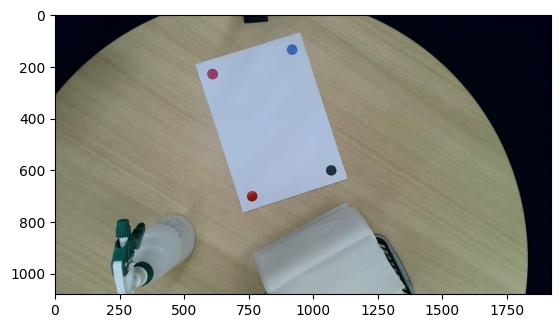

In [377]:
plt.imshow(image)

In [114]:
def get_points(file_path):
    image = cv.imread(file_path, cv.IMREAD_COLOR_RGB)
    imageBlurred = cv.medianBlur(image, 3)
    gray = cv.cvtColor(imageBlurred, cv.COLOR_RGBA2GRAY)
    thresholds = np.arange(160,190,10)
    blob_params = blobParamFunc(500, .8)
    point_list = detection(thresholds=thresholds, blob_params= blob_params, gray=gray)
    return point_list,image

newTest,image = get_points("/Users/jdreiling/Desktop/puck/puck/images/custom/michaels/medium/B/custom_michaels_medium_B_0.jpg")

In [115]:
print(newTest)

[(1049, 822), (725, 773), (1127, 321), (797, 272)]


In [116]:
def getPerm(checked, blackDot):
    for rect in checked:
        p0, p1, p2, p3 = rect
        p0, p2, p1, p3 = p0.as_tuple(), p2.as_tuple(), p1.as_tuple(), p3.as_tuple()
        perm_list = [p0,p1,p2,p3]
        ordered = orderedPermutation(blackDot[0], perm_list)
        return (ordered)

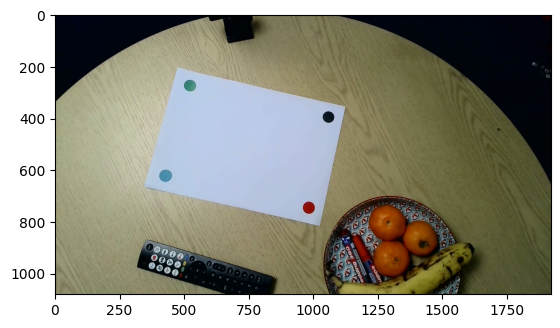

In [16]:
plt.imshow(image)

[((1049, 822), [1, 20, 25]), ((725, 773), [193, 25, 13]), ((1127, 321), [28, 142, 85]), ((797, 272), [82, 176, 182])]


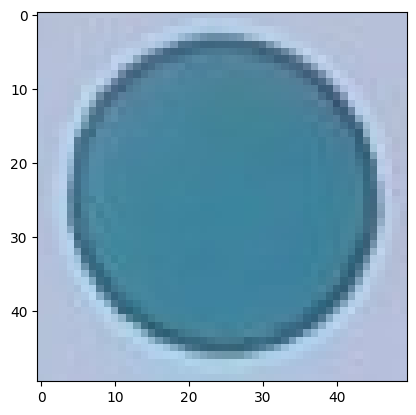

In [152]:


new_dot_list = getDotList(newTest, 25, image)
new_color_coords = getColorCoords(new_dot_list,25)
print(new_color_coords)

In [ ]:
new_color_coords = getColorCoords(new_dot_list,25)
print(new_color_coords)

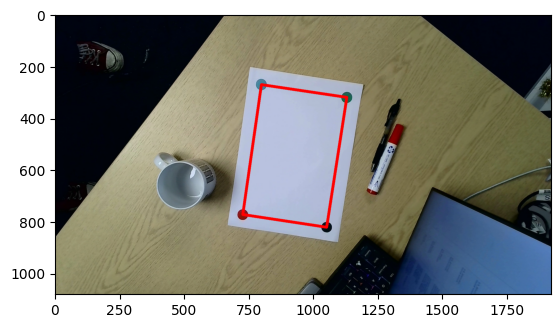

[(725, 773), (797, 272), (1127, 321)]
[[193, 25, 13], [82, 176, 182], [28, 142, 85]]
[193, 25, 13]
84
(253, 22, 34)
the closest correct is a
[82, 176, 182]
473
(253, 22, 34)
the closest correct is a
421
(254, 0, 255)
the closest correct is b
320
(0, 254, 22)
the closest correct is c
198
(0, 132, 254)
the closest correct is d
168
(0, 248, 196)
the closest correct is h
[28, 142, 85]
396
(253, 22, 34)
the closest correct is a
203
(0, 254, 22)
the closest correct is c
ahc


In [153]:
blackDot = getBlackDot(new_color_coords)
from collections import defaultdict
def get_all_rects(point_list):
    pointified = [Point.from_tuple(pt) for pt in point_list]
    pairs = list(combinations(pointified, 2))
    bucketed = [bucket(round(euc_dist(a, b)), 100) for a, b in pairs]
    tally = defaultdict(list)
    for pair, dist in zip(pairs, bucketed):
        tally[dist].append(pair)
    same_distance_pairs = dict(((dist, pairs) for dist, pairs in tally.items() if len(pairs) > 1))
    all_rects = []
    for _, pairs in same_distance_pairs.items():
        pairs_of_pairs = combinations(pairs, 2)
        rects = [(p1, p2) for (p1, p2) in pairs_of_pairs if same_midpoint(p1, p2)]
        all_rects.extend(rects)
    return all_rects

all_rects_new= (get_all_rects(newTest))
checked = (checkRects(all_rects_new))
displayFoundRect(checked, image)
ordered = getPerm(checked,blackDot)
print(ordered)
orderedColors = (orderColorCoords(ordered, new_color_coords))
print(orderedColors)
print(getColorPerm(orderedColors, trueColors_custom))

[array([206, 213, 232], dtype=uint8), array([208, 213, 235], dtype=uint8), array([206, 213, 232], dtype=uint8), array([206, 212, 234], dtype=uint8)]
circle color
[203 209 225]
[((979, 688), [249, 250, 244])]
[array([206, 214, 233], dtype=uint8), array([206, 214, 233], dtype=uint8), array([206, 214, 233], dtype=uint8), array([207, 214, 233], dtype=uint8)]
circle color
[193 198 201]
[((979, 688), [249, 250, 244]), ((692, 620), [238, 236, 220])]
[array([187, 199, 213], dtype=uint8), array([193, 205, 221], dtype=uint8), array([187, 199, 213], dtype=uint8), array([186, 198, 212], dtype=uint8)]
circle color
[173 159 122]
[((979, 688), [249, 250, 244]), ((692, 620), [238, 236, 220]), ((1087, 250), [229, 198, 141])]
[array([196, 208, 222], dtype=uint8), array([202, 215, 232], dtype=uint8), array([196, 208, 222], dtype=uint8), array([203, 214, 232], dtype=uint8)]
circle color
[180 162 116]
[((979, 688), [249, 250, 244]), ((692, 620), [238, 236, 220]), ((1087, 250), [229, 198, 141]), ((800, 175)

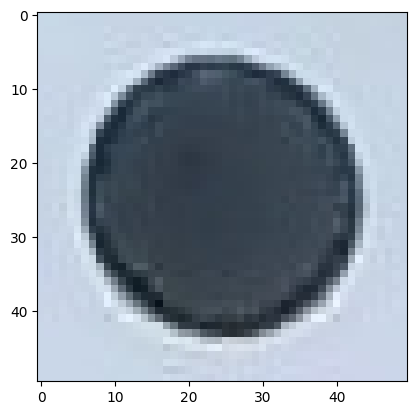

In [206]:
path ="/Users/jdreiling/Desktop/puck/puck/images/custom/john_honey/high/B/custom_john_honey_high_B_0.jpg"
def permFinder (path):
    newTest3,image2 = get_points(path)
    new_dot_list = getDotList(newTest3, 25, image2)
    # print(new_dot_list[0][1])
    new_color_coords = getColorCoords(new_dot_list,25)
    print("HEY")
    print(new_color_coords)
    blackDot = getBlackDot(new_color_coords)
    all_rects_new= (get_all_rects(newTest3))
    checked = (checkRects(all_rects_new))
    # displayFoundRect(checked, image)
    ordered = getPerm(checked,blackDot)
    orderedColors = (orderColorCoords(ordered, new_color_coords))
    # print(orderedColors)
    return (getColorPerm(orderedColors, trueColors_custom))

print(permFinder(path))

[array([206, 213, 232], dtype=uint8), array([208, 213, 235], dtype=uint8), array([206, 213, 232], dtype=uint8), array([206, 212, 234], dtype=uint8)]
circle color
[103 168 186]
[((979, 688), [126, 201, 202])]
[array([206, 214, 233], dtype=uint8), array([206, 214, 233], dtype=uint8), array([206, 214, 233], dtype=uint8), array([207, 214, 233], dtype=uint8)]
circle color
[ 63 144 111]
[((979, 688), [126, 201, 202]), ((692, 620), [78, 172, 121])]
[array([187, 199, 213], dtype=uint8), array([193, 205, 221], dtype=uint8), array([187, 199, 213], dtype=uint8), array([186, 198, 212], dtype=uint8)]
circle color
[159  43  44]
[((979, 688), [126, 201, 202]), ((692, 620), [78, 172, 121]), ((1087, 250), [210, 53, 51])]
[array([196, 208, 222], dtype=uint8), array([202, 215, 232], dtype=uint8), array([196, 208, 222], dtype=uint8), array([203, 214, 232], dtype=uint8)]
circle color
[52 64 76]
[((979, 688), [126, 201, 202]), ((692, 620), [78, 172, 121]), ((1087, 250), [210, 53, 51]), ((800, 175), [65, 76,

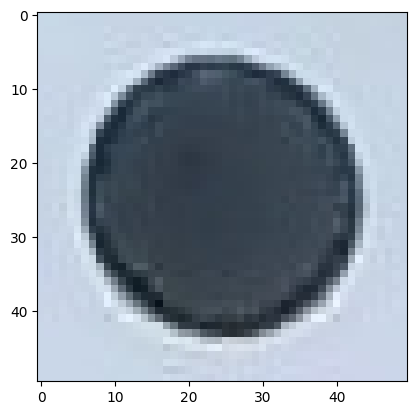

In [207]:

newTest,image = get_points(path)
new_dot_list = getDotList(newTest, 25, image)
# print(new_dot_list[0][1])
new_color_coords = getColorCoords(new_dot_list,25)
print(new_color_coords)

In [ ]:

def checkRects(all_rects):
    checked = []
    for rect in all_rects:
        p0, p2 = rect[0]
        p1, p3 = rect[1]
        rect_point_list = [p0, p2, p1, p3]
        target = Point(0,0)
        rect_point_list.sort(key= lambda p: euc_dist(p, target))
        if rect_point_list not in checked:
            checked.append(rect_point_list)
    return checked

In [ ]:
"#FD1622" ,a
"#FE00FF",b
"#00FE16",c
"#0084FE",d 
"#FEAA0D",e
"#DB4F89",f
"#EBFB26", g
"#00F8C4" h



'#FD1622', 
'#00FE16',
'#00F8C4
red purpl-red blue